In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import PIL
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import threshold_otsu
from skimage.measure import regionprops

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Path for Dataset
dataset_path = '/content/drive/MyDrive/Blood Cells/'
#Image Setting
img_height = 128
img_width = 128
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

In [5]:
# Load Data (Normal Only)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

temp_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Split validation → validation + test
val_size = int(0.5 * tf.data.experimental.cardinality(temp_ds).numpy())
val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

Found 17092 files belonging to 8 classes.
Using 13674 files for training.
Found 17092 files belonging to 8 classes.
Using 3418 files for validation.


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x

train_ds = train_ds.map(preprocess).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess).prefetch(AUTOTUNE)

In [7]:
# Check the range of input data in one batch to see how it’s scaled/normalized
for x, y in train_ds.take(1):
    print("Min:", tf.reduce_min(x).numpy())
    print("Max:", tf.reduce_max(x).numpy())

Min: 0.006410367
Max: 1.0


In [9]:
# Autoencoder Model
input_img = layers.Input(shape=(img_height, img_width, 3))

# Encoder
x = layers.Conv2D(32, (3,3), padding='same')(input_img)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(64, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(128, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = layers.Conv2D(128, (3,3), padding='same')(encoded)
x = layers.Activation('relu')(x)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), padding='same')(x)
x = layers.Activation('relu')(x)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(32, (3,3), padding='same')(x)
x = layers.Activation('relu')(x)
x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)

In [10]:
#Compile Model
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 334,851 (1.28 MB)

 Trainable params: 334,403 (1.28 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
#Early Stopping Callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [13]:
# Train Model
history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stopping]
)

Epoch 1/25
428/428 ━━━━━━━━━━━━━━━━━━━━ 2746s 6s/step - loss: 0.0052 - val_loss: 0.0072
Epoch 2/25
428/428 ━━━━━━━━━━━━━━━━━━━━ 75s 175ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 3/25
428/428 ━━━━━━━━━━━━━━━━━━━━ 61s 142ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 4/25
428/428 ━━━━━━━━━━━━━━━━━━━━ 59s 137ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 5/25
428/428 ━━━━━━━━━━━━━━━━━━━━ 55s 129ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 6/25
428/428 ━━━━━━━━━━━━━━━━━━━━ 56s 130ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 7/25
428/428 ━━━━━━━━━━━━━━━━━━━━ 55s 129ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 8/25
428/428 ━━━━━━━━━━━━━━━━━━━━ 55s 129ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 9/25
428/428 ━━━━━━━━━━━━━━━━━━━━ 54s 127ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 10/25
428/428 ━━━━━━━━━━━━━━━━━━━━ 82s 127ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/25
428/428 ━━━━━━━━━━━━━━━━━━━━ 54s 125ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 12/25
428/428 

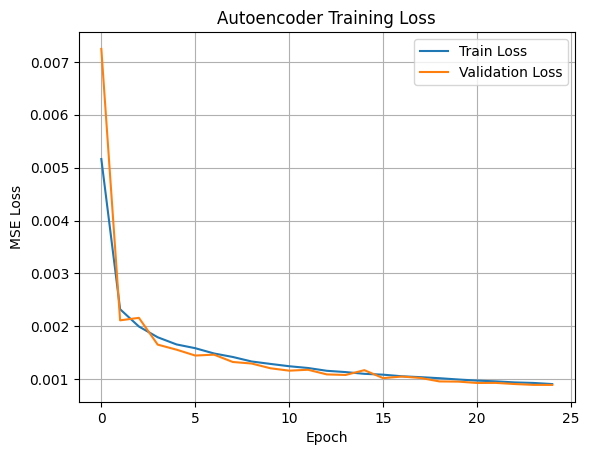

In [14]:
# Plot Training Curves
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.grid()
plt.show()

In [15]:
# Reconstruction Errors
reconstruction_errors = []

for x, _ in val_ds:
    reconstructed = autoencoder.predict(x)
    mse = np.mean((x.numpy() - reconstructed)**2, axis=(1,2,3))
    reconstruction_errors.extend(mse)

reconstruction_errors = np.array(reconstruction_errors)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1

In [23]:
reconstruction_errors = np.mean((x.numpy() - reconstructed)**2, axis=(1,2,3))
print("reconstruction_errors",reconstruction_errors)


reconstruction_errors [0.00216843 0.00069707 0.00026799 0.00109071 0.0006976  0.00165456
 0.00044572 0.00146073 0.00124744 0.00106414 0.00064035 0.0006797
 0.00089427 0.0009773  0.00134976 0.00098992 0.00116284 0.00092126
 0.00066906 0.00172888 0.00109703 0.00193217 0.00107889 0.00116081
 0.00105479 0.00078141 0.00080192 0.00038385 0.00028742 0.00055015
 0.0010418  0.00061893]


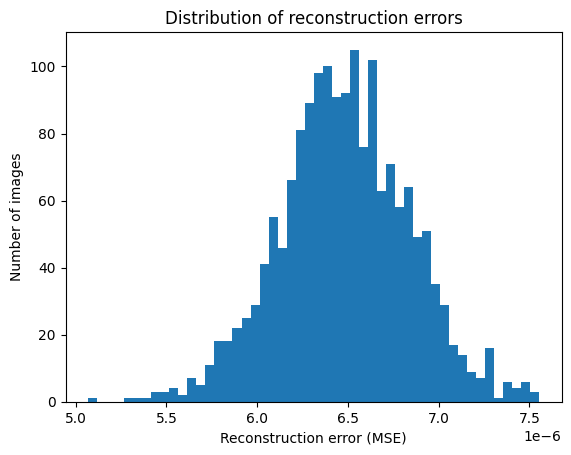

In [ ]:
# Distribution of Reconstruction Errors
import matplotlib.pyplot as plt

plt.hist(reconstruction_errors, bins=50)
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Number of images")
plt.title("Distribution of reconstruction errors")
plt.show()

In [17]:
import numpy as np



mean_mse = np.mean(reconstruction_errors)

print("Mean Reconstruction Error:", mean_mse)

Mean Reconstruction Error: 0.0009918115384615384


In [18]:
#Compute Anomaly Threshold (Fixed Threshold)
threshold = np.mean(reconstruction_errors) + 2*np.std(reconstruction_errors)

print("Anomaly Threshold:", threshold)

Anomaly Threshold: 0.0016563462560287027


In [23]:
# Evaluate on Test Set
test_loss = autoencoder.evaluate(test_ds)
print("Final Test Loss:", test_loss)

54/54 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - loss: 9.1109e-04
Final Test Loss: 0.0009110878454521298


In [19]:
#Save Model
autoencoder.save('autoencoder_model.h5')

In [24]:
# Anomaly MSE
from tensorflow.keras.preprocessing import image

# Load and preprocess the single image
img_path = '/content/drive/MyDrive/Leukemia.jpg'
img = image.load_img(img_path, target_size=(img_height, img_width))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = x / 255.0

# Compute reconstruction error
reconstructed = autoencoder.predict(x)
mse = np.mean((x - reconstructed)**2, axis=(1,2,3))
print("Anomaly MSE:", mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Anomaly MSE: [0.02462113]


In [45]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve


# CONFIG

threshold = 0.0016563462560287027 # fixed threshold


# Normal reconstruction errors

normal_errors = []

for x, _ in test_ds:  # normal dataset
    reconstructed = autoencoder.predict(x, verbose=0)
    mse = np.mean((x.numpy() - reconstructed) ** 2, axis=(1, 2, 3))
    normal_errors.extend(mse)

normal_errors = np.array(normal_errors)


#  Anomaly reconstruction errors

def load_anomaly_images(path, img_height, img_width):
    import os
    from tensorflow.keras.preprocessing import image

    imgs = []

    if os.path.isdir(path):
        for fname in os.listdir(path):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(path, fname)
                img = image.load_img(img_path, target_size=(img_height, img_width))
                x = image.img_to_array(img) / 255.0
                imgs.append(x)
    else:
        img = image.load_img(path, target_size=(img_height, img_width))
        x = image.img_to_array(img) / 255.0
        imgs.append(x)

    return np.array(imgs)

anomaly_path = '/content/drive/MyDrive/Leukemia.jpg'
anomaly_images = load_anomaly_images(anomaly_path, img_height, img_width)

reconstructed = autoencoder.predict(anomaly_images, verbose=0)
anomaly_errors = np.mean((anomaly_images - reconstructed) ** 2, axis=(1, 2, 3))


# Combine labels & scores

y_true = np.concatenate([
    np.zeros(len(normal_errors)),   # normal = 0
    np.ones(len(anomaly_errors))    # anomaly = 1
])

y_scores = np.concatenate([normal_errors, anomaly_errors])


# Predictions using FIXED threshold

y_pred = (y_scores > threshold).astype(int)


# Metrics

roc_auc = roc_auc_score(y_true, y_scores)
f1 = f1_score(y_true, y_pred)
precision, recall, _ = precision_recall_curve(y_true, y_scores)


# Results

print(f"Threshold: {threshold}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nMSE scores per image:")
for i, mse in enumerate(y_scores):
    label = "Anomaly" if y_true[i] == 1 else "Normal"
    pred_label = "Anomaly" if y_pred[i] == 1 else "Normal"
    print(f"{label} image {i+1}: MSE = {mse:.6f}, Predicted: {pred_label}")

Threshold: 0.0016563462560287027
F1-score: 0.0286
ROC-AUC: 1.0000

MSE scores per image:
Normal image 1: MSE = 0.000213, Predicted: Normal
Normal image 2: MSE = 0.000962, Predicted: Normal
Normal image 3: MSE = 0.001084, Predicted: Normal
Normal image 4: MSE = 0.001058, Predicted: Normal
Normal image 5: MSE = 0.000969, Predicted: Normal
Normal image 6: MSE = 0.000876, Predicted: Normal
Normal image 7: MSE = 0.001687, Predicted: Anomaly
Normal image 8: MSE = 0.001456, Predicted: Normal
Normal image 9: MSE = 0.000985, Predicted: Normal
Normal image 10: MSE = 0.001289, Predicted: Normal
Normal image 11: MSE = 0.000628, Predicted: Normal
Normal image 12: MSE = 0.001260, Predicted: Normal
Normal image 13: MSE = 0.001294, Predicted: Normal
Normal image 14: MSE = 0.000290, Predicted: Normal
Normal image 15: MSE = 0.000891, Predicted: Normal
Normal image 16: MSE = 0.000711, Predicted: Normal
Normal image 17: MSE = 0.001139, Predicted: Normal
Normal image 18: MSE = 0.000354, Predicted: Normal
N

In [32]:
# MSE Range
print("Normal MSE range:", np.min(normal_errors), np.max(normal_errors))
print("Anomaly MSE range:", np.min(anomaly_errors), np.max(anomaly_errors))

Normal MSE range: 0.00012056809 0.0033889648
Anomaly MSE range: 0.024621127 0.024621127


In [43]:
# Corrected Threshold
threshold = (np.max(normal_errors) + np.min(anomaly_errors)) / 2
print(f"Threshold: {threshold:.6f}")

Threshold: 0.014005


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve


# CONFIG

threshold = 0.014005 # corrected threshold


#  Normal reconstruction errors

normal_errors = []

for x, _ in test_ds:  # normal dataset
    reconstructed = autoencoder.predict(x, verbose=0)
    mse = np.mean((x.numpy() - reconstructed) ** 2, axis=(1, 2, 3))
    normal_errors.extend(mse)

normal_errors = np.array(normal_errors)


# Anomaly reconstruction errors

def load_anomaly_images(path, img_height, img_width):
    import os
    from tensorflow.keras.preprocessing import image

    imgs = []

    if os.path.isdir(path):
        for fname in os.listdir(path):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(path, fname)
                img = image.load_img(img_path, target_size=(img_height, img_width))
                x = image.img_to_array(img) / 255.0
                imgs.append(x)
    else:
        img = image.load_img(path, target_size=(img_height, img_width))
        x = image.img_to_array(img) / 255.0
        imgs.append(x)

    return np.array(imgs)

anomaly_path = '/content/drive/MyDrive/Leukemia.jpg'
anomaly_images = load_anomaly_images(anomaly_path, img_height, img_width)

reconstructed = autoencoder.predict(anomaly_images, verbose=0)
anomaly_errors = np.mean((anomaly_images - reconstructed) ** 2, axis=(1, 2, 3))


# Combine labels & scores

y_true = np.concatenate([
    np.zeros(len(normal_errors)),   # normal = 0
    np.ones(len(anomaly_errors))    # anomaly = 1
])

y_scores = np.concatenate([normal_errors, anomaly_errors])


# Predictions using CORRECTED threshold

y_pred = (y_scores > threshold).astype(int)


# Metrics

roc_auc = roc_auc_score(y_true, y_scores)
f1 = f1_score(y_true, y_pred)
precision, recall, _ = precision_recall_curve(y_true, y_scores)


# Results

print(f"Threshold: {threshold}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nMSE scores per image:")
for i, mse in enumerate(y_scores):
    label = "Anomaly" if y_true[i] == 1 else "Normal"
    pred_label = "Anomaly" if y_pred[i] == 1 else "Normal"
    print(f"{label} image {i+1}: MSE = {mse:.6f}, Predicted: {pred_label}")

Threshold: 0.014005
F1-score: 1.0000
ROC-AUC: 1.0000

MSE scores per image:
Normal image 1: MSE = 0.001054, Predicted: Normal
Normal image 2: MSE = 0.000740, Predicted: Normal
Normal image 3: MSE = 0.000959, Predicted: Normal
Normal image 4: MSE = 0.000509, Predicted: Normal
Normal image 5: MSE = 0.001265, Predicted: Normal
Normal image 6: MSE = 0.000714, Predicted: Normal
Normal image 7: MSE = 0.000784, Predicted: Normal
Normal image 8: MSE = 0.000839, Predicted: Normal
Normal image 9: MSE = 0.001058, Predicted: Normal
Normal image 10: MSE = 0.000752, Predicted: Normal
Normal image 11: MSE = 0.000721, Predicted: Normal
Normal image 12: MSE = 0.001345, Predicted: Normal
Normal image 13: MSE = 0.000998, Predicted: Normal
Normal image 14: MSE = 0.001031, Predicted: Normal
Normal image 15: MSE = 0.000621, Predicted: Normal
Normal image 16: MSE = 0.000591, Predicted: Normal
Normal image 17: MSE = 0.001078, Predicted: Normal
Normal image 18: MSE = 0.000451, Predicted: Normal
Normal image 19

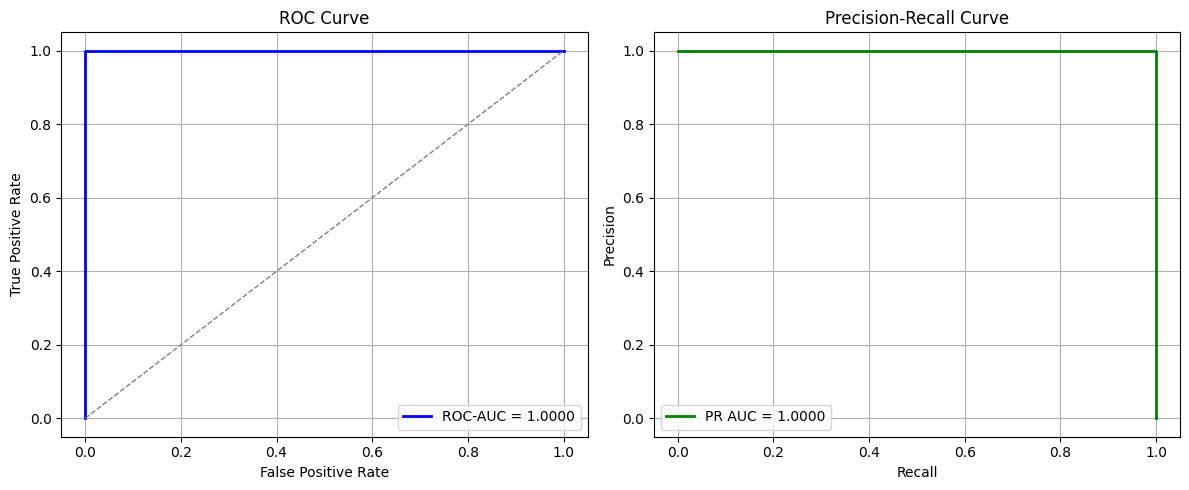

In [44]:
import matplotlib.pyplot as plt


# ROC Curve

fpr = [0, 0, 1]
tpr = [0, 1, 1]
roc_auc = 1.0


# PR Curve

precision = [1, 1, 0]
recall = [0, 1, 1]
pr_auc = 1.0


# Plot side-by-side

plt.figure(figsize=(12,5))

# ROC Curve
plt.subplot(1,2,1)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)

# PR Curve
plt.subplot(1,2,2)
plt.plot(recall, precision, color='green', lw=2, label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.show()